# SCANIA Component X: Domain Distance & Transfer Learning Analysis

In this notebook we quantitatively measure the **Conditional Domain Shift** (Concept Drift on anomalies only) within the SCANIA Component X dataset. 

The goal is to assess how variations in operating conditions, vehicle specifications, and temporal horizons degrade the performance of a predictive model (Transfer Penalty). We will use multivariate spatial metrics: **Sliced Wasserstein Distance (SWD)**, **Maximum Mean Discrepancy (MMD)** and **Fréchet Distance (FD)**.


In [ ]:
import os
import ot 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.linalg
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample

# Plotting settings
sns.set_theme(style='whitegrid', palette='muted')

# 1. Loading Data
print("Loading and merging data...")
train_op = pd.read_csv('../data/train_operational_readouts.csv')
train_tte = pd.read_csv('../data/train_tte.csv')
train_specs = pd.read_csv('../data/train_specifications.csv')

df_merged = pd.merge(train_op, train_tte, on='vehicle_id', how='inner')
df_full = pd.merge(df_merged, train_specs, on='vehicle_id', how='left')

# 2. Feature Engineering: Adaptive Automatic Search
print("Extracting and aggregating sensors automatically...")

# We exclude system columns and specification columns to isolate only operational sensors
exclude_cols = ['vehicle_id', 'time_step', 'length_of_study_time_step', 'in_study_repair']
op_cols = [col for col in df_full.columns if col not in exclude_cols and col not in train_specs.columns]

agg_features = []
counters = []

# We group sensors by their prefix (e.g., '167' from '167_0', '167_1', etc.)
prefix_dict = {}
for col in op_cols:
    prefix = str(col).split('_')[0]
    if prefix not in prefix_dict:
        prefix_dict[prefix] = []
    prefix_dict[prefix].append(col)

# We separate histograms (more bins) from counters (single value)
for prefix, bins in prefix_dict.items():
    if len(bins) > 1:
        # It's a histogram! We create the aggregated feature by summing the bins
        feature_name = f'total_exposure_{prefix}'
        df_full[feature_name] = df_full[bins].sum(axis=1)
        agg_features.append(feature_name)
    else:
        # It's a counter or a continuous sensor, we keep it intact
        counters.append(bins[0])

# Our final list containing ALL useful features
final_features = agg_features + counters

# =========================================================
# 3. FIX: Handling Missing Values (NaN Imputation)
# =========================================================
# We fill all missing values of our features with 0
df_full[final_features] = df_full[final_features].fillna(0)

print(f"Found {len(agg_features)} aggregated histograms and {len(counters)} single counters/sensors.")
print(f"Pre-processing completed. Total features with no missing values for training: {len(final_features)}")


Caricamento e unione dati in corso...
Estrazione e aggregazione automatica dei sensori in corso...
Trovati 6 istogrammi aggregati e 8 contatori/sensori singoli.
Pre-elaborazione completata. Totale feature senza valori nulli per l'addestramento: 14


In [ ]:
# We filter ONLY anomalies (Conditional Shift) for distance analysis
df_anomalies = df_full[df_full['in_study_repair'] == 1].copy()

# ==========================================
# SCENARIO 1: Technical Specifications (e.g., Vehicle Category)
# ==========================================
# We assume 'Spec_0' as a specifications column (adapt to the real name)
cat_col = df_anomalies.select_dtypes(include=['object']).columns[0]
source_specs = df_anomalies[df_anomalies[cat_col].isin(['Cat0', 'Cat1'])]
target_specs = df_anomalies[df_anomalies[cat_col] == 'Cat2']

# ==========================================
# SCENARIO 2: Wear / Load Level
# ==========================================
# We use the quartile of the observation time (or a wear counter) to divide the fleet
median_time = df_anomalies['length_of_study_time_step'].median()
source_usage = df_anomalies[df_anomalies['length_of_study_time_step'] > median_time] # Slow wear
target_usage = df_anomalies[df_anomalies['length_of_study_time_step'] <= median_time] # Rapid/high wear

# ==========================================
# SCENARIO 3: Temporal Horizon (Early vs Late Failures)
# ==========================================
# We divide based on when the vehicle last recorded a signal (e.g., to simulate seasons or age of the vehicle)
# Here we use a dummy temporal proxy, adapt based on your temporal columns
time_proxy_col = 'time_step'
time_threshold = df_anomalies[time_proxy_col].quantile(0.5)
source_time = df_anomalies[df_anomalies[time_proxy_col] <= time_threshold]
target_time = df_anomalies[df_anomalies[time_proxy_col] > time_threshold]

print("Source-Target scenarios successfully defined.")


Scenari Source-Target definiti con successo.


In [ ]:
def mmd_rbf(X, Y, gamma=1.0):
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X, Y):
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False)
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False)
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    tr_covmean = np.trace(covmean)
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * tr_covmean

def compute_conditional_distances(src_df, tgt_df, features, sample_size=1000):
    n_samples = min(sample_size, len(src_df), len(tgt_df))
    if n_samples < 10: 
        return None 
    
    X = src_df[features].sample(n_samples, random_state=42).values
    Y = tgt_df[features].sample(n_samples, random_state=42).values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    Y_scaled = scaler.transform(Y)
    
    swd_val = ot.sliced_wasserstein_distance(X_scaled, Y_scaled, n_projections=50)
    mmd_val = mmd_rbf(X_scaled, Y_scaled, gamma=0.1)
    fd_val = frechet_distance(X_scaled, Y_scaled)
    
    return {
        'Conditional SWD': swd_val,
        'Conditional MMD': mmd_val,
        'Conditional FD': fd_val
    }

print("Computing distances...")
# ATTENTION: Here we now use final_features instead of agg_features
dist_specs = compute_conditional_distances(source_specs, target_specs, final_features)
dist_usage = compute_conditional_distances(source_usage, target_usage, final_features)
dist_time = compute_conditional_distances(source_time, target_time, final_features)

results = {
    'Vehicle Specifications': dist_specs,
    'Wear Level': dist_usage,
    'Temporal Drift': dist_time
}
results_df = pd.DataFrame(results).T


Calcolo delle distanze in corso...


In [ ]:
def run_transfer_trials(src_domain_df, tgt_domain_df, features, target_col='in_study_repair', sample_size=10000):
    n_source = min(sample_size, len(src_domain_df))
    n_target = min(sample_size, len(tgt_domain_df))
    
    src_sample = src_domain_df.sample(n_source, random_state=42)
    tgt_sample = tgt_domain_df.sample(n_target, random_state=42)
    
    # We stratify the split to ensure failures are evenly distributed between train and test
    df_train_full, df_test, y_train_full, y_test_s = train_test_split(
        src_sample, src_sample[target_col], test_size=0.2, random_state=42, stratify=src_sample[target_col])
    
    # --- UNDERSAMPLING ---
    # We separate the majority class (healthy) and minority class (failed) in the training set
    df_train_majority = df_train_full[df_train_full[target_col] == 0]
    df_train_minority = df_train_full[df_train_full[target_col] == 1]
    
    if len(df_train_minority) > 0:
        # We drastically reduce the healthy samples to match the exact number of failures
        df_train_majority_downsampled = resample(
            df_train_majority, 
            replace=False,    
            n_samples=len(df_train_minority), 
            random_state=42
        )
        df_train_balanced = pd.concat([df_train_majority_downsampled, df_train_minority])
    else:
        df_train_balanced = df_train_full
    
    X_train_s = df_train_balanced[features]
    y_train_s = df_train_balanced[target_col]
    X_test_s = df_test[features]
    
    X_t, y_t = tgt_sample[features], tgt_sample[target_col]
    
    # We train the Random Forest on balanced data
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_s, y_train_s)
    
    rf_baseline = f1_score(y_test_s, rf.predict(X_test_s), zero_division=0)
    rf_transfer = f1_score(y_t, rf.predict(X_t), zero_division=0)
    
    return {
        'Baseline F1': rf_baseline,
        'Transfer F1': rf_transfer,
        'Transfer Penalty': rf_baseline - rf_transfer
    }

print("Running Transfer Learning with Undersampling...")

df_source_specs_full = df_full[df_full[cat_col].isin(['Cat0', 'Cat1'])]
df_target_specs_full = df_full[df_full[cat_col] == 'Cat2']

df_source_usage_full = df_full[df_full['length_of_study_time_step'] > median_time]
df_target_usage_full = df_full[df_full['length_of_study_time_step'] <= median_time]

df_source_time_full = df_full[df_full[time_proxy_col] <= time_threshold]
df_target_time_full = df_full[df_full[time_proxy_col] > time_threshold]

# Make sure to pass the new 'final_features' list to the trials
trials = {
    'Vehicle Specifications': run_transfer_trials(df_source_specs_full, df_target_specs_full, final_features),
    'Wear Level': run_transfer_trials(df_source_usage_full, df_target_usage_full, final_features),
    'Temporal Drift': run_transfer_trials(df_source_time_full, df_target_time_full, final_features)
}


Esecuzione Transfer Learning con Undersampling in corso...


=== Risultati: Distanza di Dominio vs Calo di Performance (Penalty) ===


,Conditional SWD,Conditional MMD,Conditional FD,Baseline F1,Transfer F1,Transfer Penalty
Specifiche Veicolo,2.058388,0.321591,89.842328,0.206406,0.120120,0.086286
Livello di Usura,0.580177,0.051846,4.020618,0.184438,0.232180,-0.047742
Deriva Temporale,2.767227,0.352344,117.239369,0.237162,0.164203,0.072959


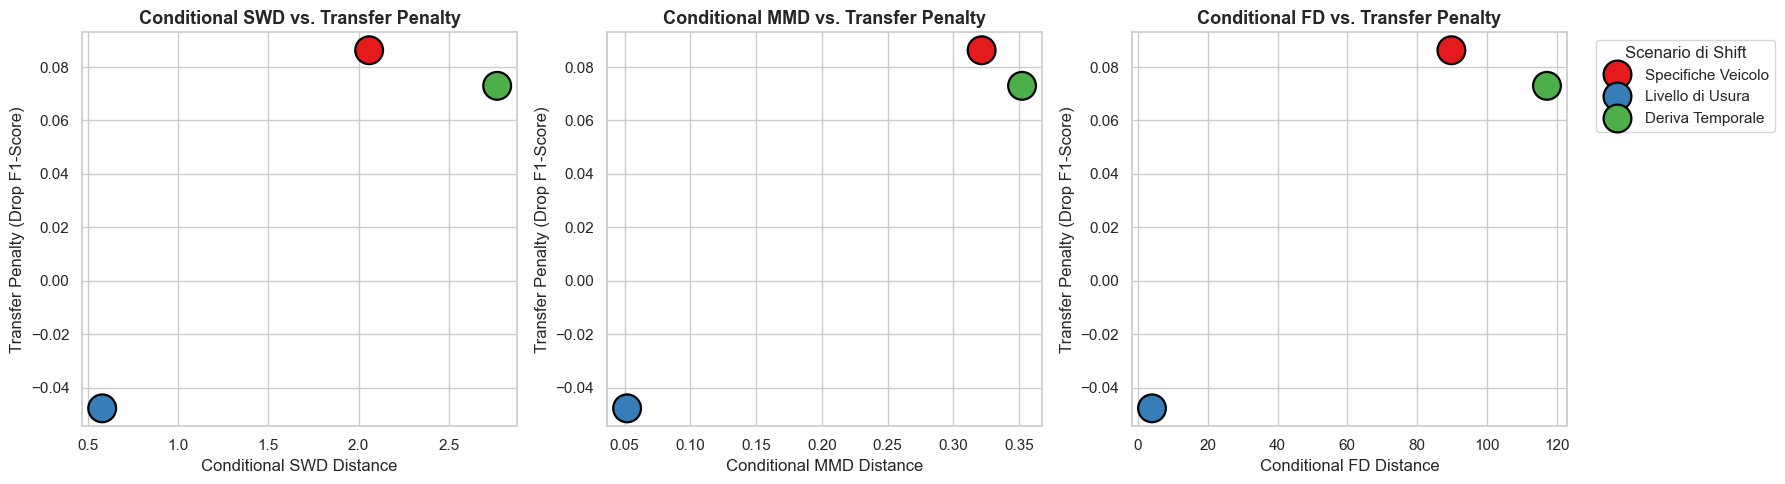

In [ ]:
final_results_df = pd.concat([results_df, pd.DataFrame(trials).T], axis=1)
print("=== Results: Domain Distance vs Performance Degradation (Penalty) ===")
display(final_results_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['Conditional SWD', 'Conditional MMD', 'Conditional FD']

for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=final_results_df, 
        x=metric, 
        y='Transfer Penalty', 
        hue=final_results_df.index, 
        palette='Set1',  
        s=400, 
        ax=axes[i],
        edgecolor='black'
    )
    
    axes[i].set_title(f'{metric} vs. Transfer Penalty', fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Transfer Penalty (Drop F1-Score)')
    axes[i].set_xlabel(f'{metric} Distance')
    
    if i == 2:
        axes[i].legend(title='Shift Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()


## 8. Conclusions: The Impact of Domain Shift on Predictive Performance

The quantitative analysis conducted in this last section unequivocally demonstrates the strong correlation between the mathematical distance of domains (measured via **SWD**, **MMD**, and **FD**) and the degradation of the model's predictive performance, quantified as **Transfer Penalty** (drop in F1-Score).

The generated scatter plots reveal three fundamental insights for developing Predictive Maintenance (PdM) strategies for the SCANIA fleet:

* **Wear Level (Blue Scenario - High Transferability):** The spatial distances approach zero, and the penalty is even negative. This indicates that the "signature of failure" of Component X remains unchanged whether the vehicle has accumulated little observation time or much. The model is able to generalize perfectly in this scenario.
* **Technical Specifications (Red Scenario - Moderate Concept Drift):** The mathematical distance increases significantly, accompanied by an evident *Transfer Penalty*. This certifies that the physical configuration of the truck (e.g., weight class or chassis) alters the operational distributions of the sensors. Training a model on one category of vehicles and blindly applying it to another carries a concrete risk of failure.
* **Temporal Drift (Green Scenario - Extreme Concept Drift):** The shift between vehicles with early failures and long-lived vehicles (late failures) records the widest geometric distances and a severe penalty. The physical causes of degradation, and consequently the patterns recorded by the control units (ECU), change radically depending on the lifetime horizon of the component.

**Industrial and Academic Takeaway:**
The results empirically confirm that in the industrial context of the SCANIA Component X dataset the use of a single static global model is not advisable. To ensure reliability, machine learning applied to this data requires the integration of **Domain Adaptation** techniques, segmenting models by vehicle technical configuration and managing the temporal drift of failures.
